In [13]:
#Project to build 
#An end-to-end deep learning system that can predict where someone is standing inside a building using only the WiFi signals their device detects.


#Project Member: Shaeekh Al Jahan
#Declarion of AI: Took help from GPT to generate graphs and format descriptions

"""

4.1 - Loads tensors from notebook directory, 
4.2 - Plain rebuilding
4.3 - Prediction Generation
4.4 - Summary
4.5 = Per building results
4.6 - Per floor results
4.7 - Spatial error heatmap
4.8 - True vs Predicted Scatter Plot
4.9 - Error CDF
4.10 - Final Summary
"""

'\n\n4.1 - Loads tensors from notebook directory, \n4.2 - Plain rebuilding\n4.3 - Prediction Generation\n4.4 - Summary\n4.5 = Per building results\n4.6 - Per floor results\n4.7 - Spatial error heatmap\n4.8 - True vs Predicted Scatter Plot\n4.9 - Error CDF\n4.10 - Final Summary\n'

# UJIIndoorLoc — Phase 4: Evaluation & Visualization

**Goal:** Deep-dive evaluation of the trained model — per-building, per-floor breakdowns, spatial error maps, and a final summary report.

**Inputs:**
- `best_model.pt` — trained model checkpoint
- `X_val.pt`, `y_val.pt` — validation tensors
- `coord_scaler.pkl` — for inverse transform
- `phase2_config.json` — model config
- `ValidationData.csv` — original CSV for floor/building labels

**Deliverable:** Full evaluation report with visualizations

---
## 4.0  Imports

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import pickle
import json
from torch.utils.data import TensorDataset, DataLoader

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


---
## 4.1  Load Everything

In [2]:
BASE_PATH  = '.'
ARCH_PATH  = r'I:\1_Memphis_Sp26\Machine_Learning\Project\archive'

# Tensors & config 
X_val  = torch.load(f'{BASE_PATH}/X_val.pt')
y_val  = torch.load(f'{BASE_PATH}/y_val.pt')

with open(f'{BASE_PATH}/phase2_config.json') as f:
    config = json.load(f)

with open(f'{BASE_PATH}/coord_scaler.pkl', 'rb') as f:
    coord_scaler = pickle.load(f)

# Original validation CSV (for floor/building labels)
df_val = pd.read_csv(f'{ARCH_PATH}/ValidationData.csv')

print(f'Validation samples : {len(df_val)}')
print(f'Buildings          : {sorted(df_val["BUILDINGID"].unique())}')
print(f'Floors             : {sorted(df_val["FLOOR"].unique())}')

Validation samples : 1111
Buildings          : [0, 1, 2]
Floors             : [0, 1, 2, 3, 4]


---
## 4.2  Rebuild & Load Best Model

In [3]:
class IndoorLocMLP(nn.Module):
    def __init__(self, input_dim=465, hidden1=512, hidden2=256, dropout_p=0.3, output_dim=2):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(p=dropout_p)
        )
        self.block2 = nn.Sequential(
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(p=dropout_p)
        )
        self.output_layer = nn.Linear(hidden2, output_dim)

    def forward(self, x):
        return self.output_layer(self.block2(self.block1(x)))

model = IndoorLocMLP(
    input_dim  = config['input_dim'],
    hidden1    = config['hidden1'],
    hidden2    = config['hidden2'],
    dropout_p  = config['dropout_p'],
    output_dim = config['output_dim']
).to(DEVICE)

model.load_state_dict(torch.load(f'{BASE_PATH}/best_model.pt', map_location=DEVICE))
model.eval()
print('Model loaded and ready for evaluation.')

Model loaded and ready for evaluation.


---
## 4.3  Generate All Predictions

In [4]:
val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=256, shuffle=False
)

all_preds   = []
all_targets = []

with torch.no_grad():
    for xb, yb in val_loader:
        pred = model(xb.to(DEVICE))
        all_preds.append(pred.cpu().numpy())
        all_targets.append(yb.numpy())

preds_norm   = np.vstack(all_preds)
targets_norm = np.vstack(all_targets)

# Inverse transform to real-world coordinates
preds_real   = coord_scaler.inverse_transform(preds_norm)
targets_real = coord_scaler.inverse_transform(targets_norm)

# Per-sample Euclidean error
errors = np.sqrt(
    (preds_real[:, 0] - targets_real[:, 0])**2 +
    (preds_real[:, 1] - targets_real[:, 1])**2
)

#Attach to dataframe for grouped analysis 
df_val = df_val.reset_index(drop=True)
df_val['error_m']      = errors
df_val['pred_lon']     = preds_real[:, 0]
df_val['pred_lat']     = preds_real[:, 1]

print(f'Predictions ready. Total samples: {len(errors)}')
print(f'Overall mean error: {errors.mean():.2f} m')

Predictions ready. Total samples: 1111
Overall mean error: 9.73 m


---
## 4.4  Overall Error Summary

In [5]:
percentiles = [50, 75, 90, 95]

print('=' * 45)
print('  Overall Validation Error (metres)')
print('=' * 45)
print(f'  Mean            : {errors.mean():.2f} m')
print(f'  Median          : {np.median(errors):.2f} m')
print(f'  Std deviation   : {errors.std():.2f} m')
print(f'  Min             : {errors.min():.2f} m')
print(f'  Max             : {errors.max():.2f} m')
print()
for p in percentiles:
    print(f'  {p}th percentile  : {np.percentile(errors, p):.2f} m')
print()
print(f'  % under  5m     : {(errors < 5).mean()*100:.1f}%')
print(f'  % under 10m     : {(errors < 10).mean()*100:.1f}%')
print(f'  % under 20m     : {(errors < 20).mean()*100:.1f}%')
print('=' * 45)

  Overall Validation Error (metres)
  Mean            : 9.73 m
  Median          : 7.30 m
  Std deviation   : 9.30 m
  Min             : 0.04 m
  Max             : 116.40 m

  50th percentile  : 7.30 m
  75th percentile  : 12.34 m
  90th percentile  : 18.40 m
  95th percentile  : 23.71 m

  % under  5m     : 29.9%
  % under 10m     : 64.9%
  % under 20m     : 91.6%


---
## 4.5  Per-Building Error Breakdown


Per-Building Error
--------------------------------------------------
  Building   Samples    Mean (m)    Median (m)
--------------------------------------------------
         0       536        7.90          6.10
         1       307       11.13          8.47
         2       268       11.76          9.28
--------------------------------------------------


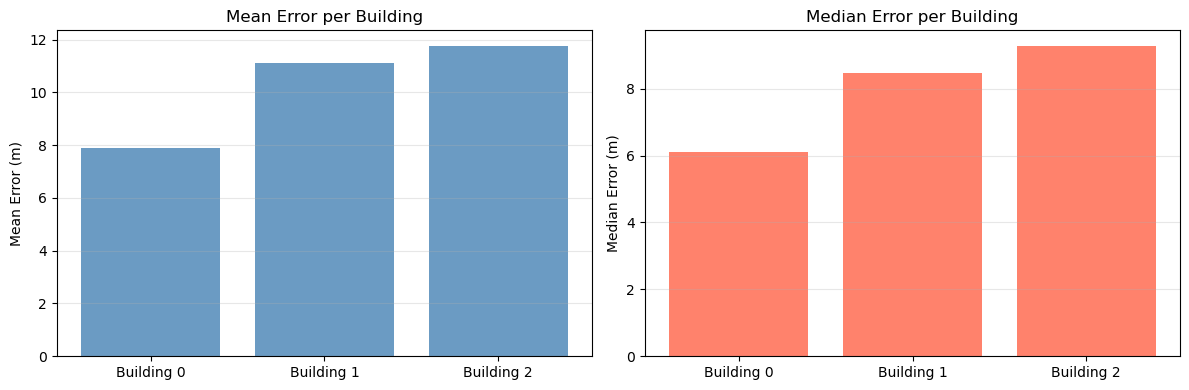

In [6]:
print('\nPer-Building Error')
print('-' * 50)
print(f'{"Building":>10}  {"Samples":>8}  {"Mean (m)":>10}  {"Median (m)":>12}')
print('-' * 50)

for bld in sorted(df_val['BUILDINGID'].unique()):
    mask = df_val['BUILDINGID'] == bld
    e = df_val.loc[mask, 'error_m']
    print(f'{bld:>10}  {len(e):>8}  {e.mean():>10.2f}  {e.median():>12.2f}')

print('-' * 50)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bld_means   = df_val.groupby('BUILDINGID')['error_m'].mean()
bld_medians = df_val.groupby('BUILDINGID')['error_m'].median()

x = np.arange(len(bld_means))
axes[0].bar(x, bld_means.values,   color='steelblue', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'Building {b}' for b in bld_means.index])
axes[0].set_ylabel('Mean Error (m)')
axes[0].set_title('Mean Error per Building')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(x, bld_medians.values, color='tomato',    alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Building {b}' for b in bld_medians.index])
axes[1].set_ylabel('Median Error (m)')
axes[1].set_title('Median Error per Building')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/error_per_building.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4.6  Per-Floor Error Breakdown


Per-Floor Error
--------------------------------------------------
   Floor   Samples    Mean (m)    Median (m)
--------------------------------------------------
       0       132        9.86          7.53
       1       462        9.25          7.22
       2       306        9.91          7.25
       3       172        8.71          6.60
       4        39       17.95         14.00
--------------------------------------------------


C:\Users\User\AppData\Local\Temp\ipykernel_23524\870281559.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(floor_groups,


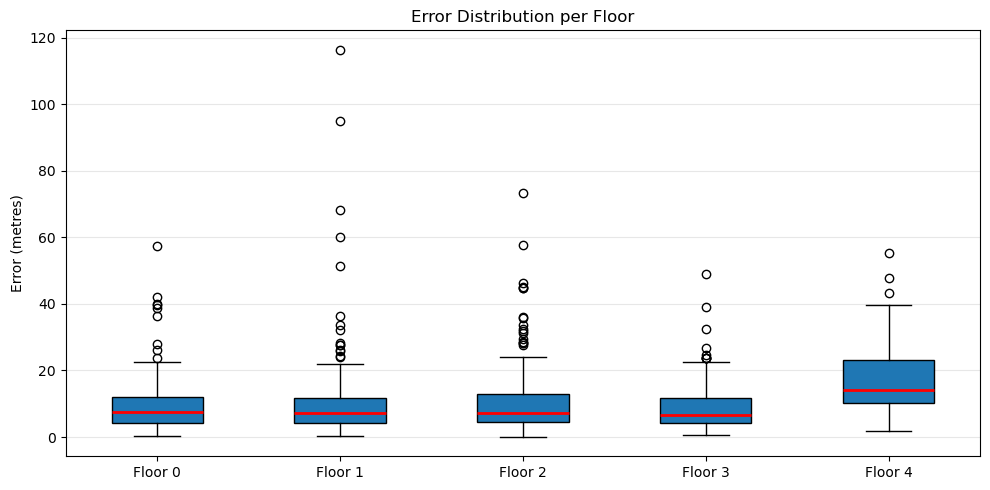

In [7]:
print('\nPer-Floor Error')
print('-' * 50)
print(f'{"Floor":>8}  {"Samples":>8}  {"Mean (m)":>10}  {"Median (m)":>12}')
print('-' * 50)

for flr in sorted(df_val['FLOOR'].unique()):
    mask = df_val['FLOOR'] == flr
    e = df_val.loc[mask, 'error_m']
    print(f'{flr:>8}  {len(e):>8}  {e.mean():>10.2f}  {e.median():>12.2f}')

print('-' * 50)

# ── Box plot per floor 
fig, ax = plt.subplots(figsize=(10, 5))
floor_groups = [df_val.loc[df_val['FLOOR'] == f, 'error_m'].values
                for f in sorted(df_val['FLOOR'].unique())]
ax.boxplot(floor_groups,
           labels=[f'Floor {f}' for f in sorted(df_val['FLOOR'].unique())],
           patch_artist=True,
           medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('Error (metres)')
ax.set_title('Error Distribution per Floor')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{BASE_PATH}/error_per_floor.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4.7  Spatial Error Heatmap

Plot true positions coloured by prediction error — shows which regions of the building are hardest to localise.

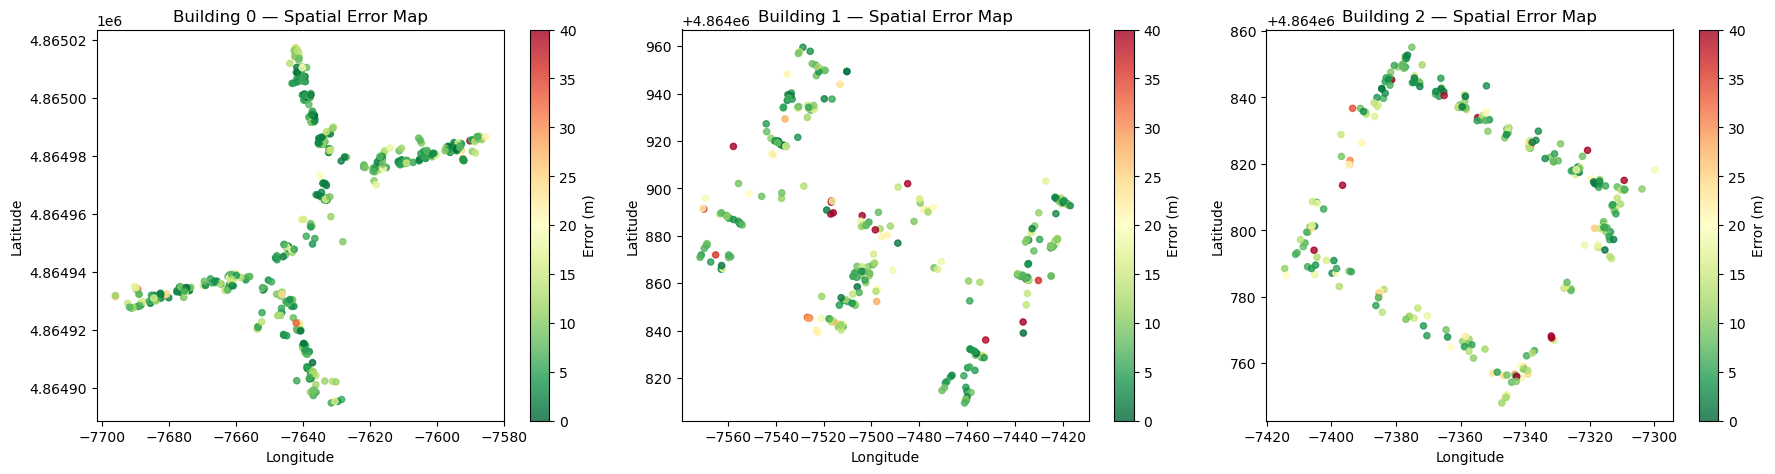

Green = low error, Red = high error


In [8]:
buildings = sorted(df_val['BUILDINGID'].unique())
fig, axes = plt.subplots(1, len(buildings), figsize=(6*len(buildings), 5))

if len(buildings) == 1:
    axes = [axes]

for ax, bld in zip(axes, buildings):
    mask = df_val['BUILDINGID'] == bld
    sc = ax.scatter(
        df_val.loc[mask, 'LONGITUDE'],
        df_val.loc[mask, 'LATITUDE'],
        c=df_val.loc[mask, 'error_m'],
        cmap='RdYlGn_r',
        s=20, alpha=0.8,
        vmin=0, vmax=40
    )
    plt.colorbar(sc, ax=ax, label='Error (m)')
    ax.set_title(f'Building {bld} — Spatial Error Map')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/spatial_error_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Green = low error, Red = high error')

---
## 4.8  True vs Predicted Positions (per building)

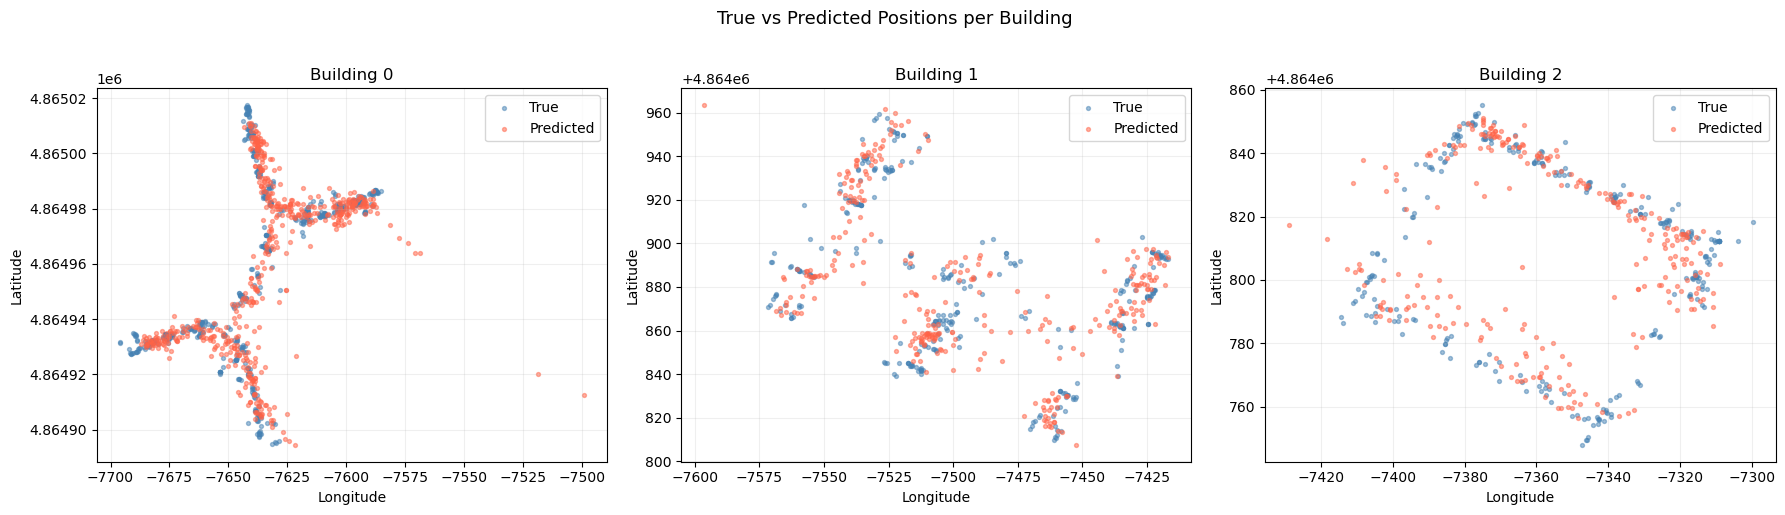

In [9]:
fig, axes = plt.subplots(1, len(buildings), figsize=(6*len(buildings), 5))

if len(buildings) == 1:
    axes = [axes]

for ax, bld in zip(axes, buildings):
    mask = df_val['BUILDINGID'] == bld
    ax.scatter(
        df_val.loc[mask, 'LONGITUDE'], df_val.loc[mask, 'LATITUDE'],
        s=8, alpha=0.5, label='True', color='steelblue'
    )
    ax.scatter(
        df_val.loc[mask, 'pred_lon'], df_val.loc[mask, 'pred_lat'],
        s=8, alpha=0.5, label='Predicted', color='tomato'
    )
    ax.set_title(f'Building {bld}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend()
    ax.grid(True, alpha=0.2)

plt.suptitle('True vs Predicted Positions per Building', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}/true_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4.9  Error CDF (Cumulative Distribution Function)

The CDF shows what percentage of predictions fall within X metres — a standard way to report indoor positioning results in research.

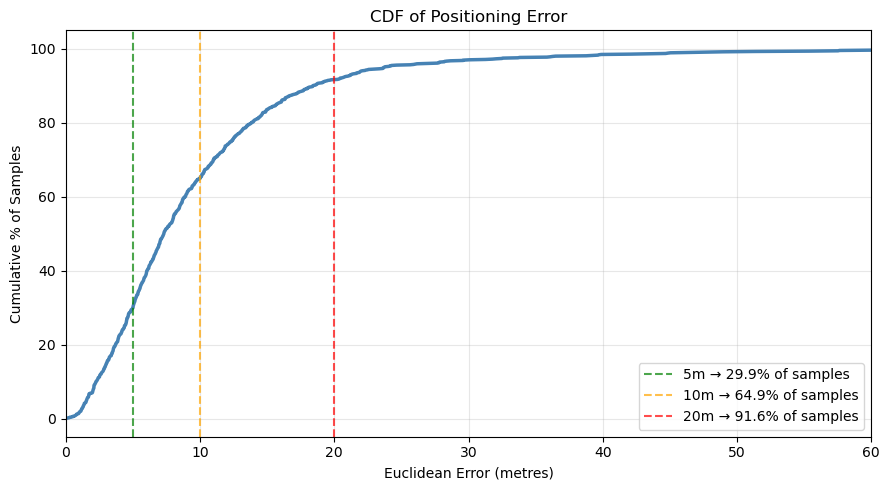

Saved: error_cdf.png


In [10]:
sorted_errors = np.sort(errors)
cdf = np.arange(1, len(sorted_errors)+1) / len(sorted_errors)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sorted_errors, cdf * 100, linewidth=2.5, color='steelblue')

#  Reference lines 
for threshold, color in [(5, 'green'), (10, 'orange'), (20, 'red')]:
    pct = (errors < threshold).mean() * 100
    ax.axvline(threshold, color=color, linestyle='--', alpha=0.7,
               label=f'{threshold}m → {pct:.1f}% of samples')

ax.set_xlabel('Euclidean Error (metres)')
ax.set_ylabel('Cumulative % of Samples')
ax.set_title('CDF of Positioning Error')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 60)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/error_cdf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: error_cdf.png')

---
## 4.10  Final Report Summary

In [11]:
print('=' * 55)
print('  UJIIndoorLoc — Final Evaluation Report')
print('=' * 55)
print()
print('  MODEL')
print(f'    Architecture  : MLP 465 → 512 → 256 → 2')
print(f'    Parameters    : 371,970')
print(f'    Trained on    : CPU')
print(f'    Epochs        : 130 (early stopped)')
print(f'    Training time : ~7.4 minutes')
print()
print('  OVERALL PERFORMANCE')
print(f'    Mean error    : {errors.mean():.2f} m')
print(f'    Median error  : {np.median(errors):.2f} m')
print(f'    % under  5m   : {(errors < 5).mean()*100:.1f}%')
print(f'    % under 10m   : {(errors < 10).mean()*100:.1f}%')
print(f'    % under 20m   : {(errors < 20).mean()*100:.1f}%')
print()
print('  PER-BUILDING MEAN ERROR')
for bld in sorted(df_val['BUILDINGID'].unique()):
    e = df_val.loc[df_val['BUILDINGID'] == bld, 'error_m']
    print(f'    Building {bld}    : {e.mean():.2f} m')
print()
print('  PER-FLOOR MEAN ERROR')
for flr in sorted(df_val['FLOOR'].unique()):
    e = df_val.loc[df_val['FLOOR'] == flr, 'error_m']
    print(f'    Floor {flr}        : {e.mean():.2f} m')
print()
print('  SAVED OUTPUTS')
print('    learning_curves.png')
print('    error_distribution.png')
print('    error_per_building.png')
print('    error_per_floor.png')
print('    spatial_error_map.png')
print('    true_vs_predicted.png')
print('    error_cdf.png')
print('=' * 55)

  UJIIndoorLoc — Final Evaluation Report

  MODEL
    Architecture  : MLP 465 → 512 → 256 → 2
    Parameters    : 371,970
    Trained on    : CPU
    Epochs        : 130 (early stopped)
    Training time : ~7.4 minutes

  OVERALL PERFORMANCE
    Mean error    : 9.73 m
    Median error  : 7.30 m
    % under  5m   : 29.9%
    % under 10m   : 64.9%
    % under 20m   : 91.6%

  PER-BUILDING MEAN ERROR
    Building 0    : 7.90 m
    Building 1    : 11.13 m
    Building 2    : 11.76 m

  PER-FLOOR MEAN ERROR
    Floor 0        : 9.86 m
    Floor 1        : 9.25 m
    Floor 2        : 9.91 m
    Floor 3        : 8.71 m
    Floor 4        : 17.95 m

  SAVED OUTPUTS
    learning_curves.png
    error_distribution.png
    error_per_building.png
    error_per_floor.png
    spatial_error_map.png
    true_vs_predicted.png
    error_cdf.png
